In [2]:
import matplotlib.pyplot as plt
from pprint import pprint
import seaborn as sns
import pandas as pd
import numpy as np
from pymongo import MongoClient
import string
import nltk
import tqdm
import re

## Loading in and cleaning review data

In [3]:
# Connecting to mongodb
uri = 'mongodb://localhost:27017'
client = MongoClient(uri)
client.list_database_names()

['admin', 'config', 'local', 'reviews']

In [4]:
# connecting to my reviews database
db = client['reviews']
col = db['google_reviews']
num_docs = col.count_documents({})
print(f"{num_docs} Total documents in 'google_reviews' collection")

11898 Total documents in 'google_reviews' collection


In [5]:
## Reading into a pandas dataframe
df = pd.DataFrame(list(col.find()))
cols_to_use = ['_id', 'author', 'city', 'description', 'last_modified_date', 'likes', 'owner_responses', 'rating', 'review_date', 'source']
df = df[cols_to_use]

In [6]:
def clean_description(val):
    if 'en' in val.keys():
        return val['en']
    else:
        return None

In [7]:
def clean_owner_response(val):
    if 'en' in val.keys():
        return val['en']['text']
    else:
        return None

In [8]:
review = df['description'].apply(clean_description)
df['review'] = review
df['owner_responses'] = df['owner_responses'].apply(clean_owner_response)

In [9]:
df.drop(columns=['description', 'source'], inplace=True, errors='ignore')

## Loading in and cleaning Train Data

In [10]:
train_df = pd.read_csv('./../deceptive-opinion.csv')

In [11]:
train_df=train_df.drop(['hotel', 'source'],axis=1)
train_df.head()

,deceptive,polarity,text
0,truthful,positive,We stayed for a one night getaway with family ...
1,truthful,positive,Triple A rate with upgrade to view room was le...
2,truthful,positive,This comes a little late as I'm finally catchi...
3,truthful,positive,The Omni Chicago really delivers on all fronts...
4,truthful,positive,I asked for a high floor away from the elevato...


In [12]:
def text_cleaning(text):
    '''
    Make text lowercase, remove text in square brackets,remove links,remove special characters
    and remove words containing numbers.
    '''
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r"\\W"," ",text) # remove special chars
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    
    return text  
train_df['text'] = train_df['text'].apply(text_cleaning)

In [13]:
## Removing stopwords
from nltk.corpus import stopwords
from nltk import pos_tag, pos_tag_sents
stop = stopwords.words('english')

In [14]:
train_df['review_sans_stop'] = train_df['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
train_df.head()

,deceptive,polarity,text,review_sans_stop
0,truthful,positive,we stayed for a one night getaway with family ...,stayed one night getaway family thursday tripl...
1,truthful,positive,triple a rate with upgrade to view room was le...,triple rate upgrade view room less also includ...
2,truthful,positive,this comes a little late as im finally catchin...,comes little late im finally catching reviews ...
3,truthful,positive,the omni chicago really delivers on all fronts...,omni chicago really delivers fronts spaciousne...
4,truthful,positive,i asked for a high floor away from the elevato...,asked high floor away elevator got room pleasa...


In [15]:
## part of speech tagging
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /home/gabe-j/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/gabe-j/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [16]:
from textblob import TextBlob
def pos(review_sans_stop):
    return TextBlob(review_sans_stop).tags

In [17]:
os = train_df.review_sans_stop.apply(pos)
os1 = pd.DataFrame(os)
os1.head()

,review_sans_stop
0,"[(stayed, JJ), (one, CD), (night, NN), (getawa..."
1,"[(triple, JJ), (rate, NN), (upgrade, JJ), (vie..."
2,"[(comes, VBZ), (little, JJ), (late, JJ), (im, ..."
3,"[(omni, NNS), (chicago, VBP), (really, RB), (d..."
4,"[(asked, VBN), (high, JJ), (floor, NN), (away,..."


In [18]:
os1['pos'] = os1['review_sans_stop'].map(lambda x: " ".join(["/".join(x) for x in x]))
result = pd.merge(train_df, os1, right_index=True, left_index=True)
result.head()

,deceptive,polarity,text,review_sans_stop_x,review_sans_stop_y,pos
0,truthful,positive,we stayed for a one night getaway with family ...,stayed one night getaway family thursday tripl...,"[(stayed, JJ), (one, CD), (night, NN), (getawa...",stayed/JJ one/CD night/NN getaway/NN family/NN...
1,truthful,positive,triple a rate with upgrade to view room was le...,triple rate upgrade view room less also includ...,"[(triple, JJ), (rate, NN), (upgrade, JJ), (vie...",triple/JJ rate/NN upgrade/JJ view/NN room/NN l...
2,truthful,positive,this comes a little late as im finally catchin...,comes little late im finally catching reviews ...,"[(comes, VBZ), (little, JJ), (late, JJ), (im, ...",comes/VBZ little/JJ late/JJ im/NN finally/RB c...
3,truthful,positive,the omni chicago really delivers on all fronts...,omni chicago really delivers fronts spaciousne...,"[(omni, NNS), (chicago, VBP), (really, RB), (d...",omni/NNS chicago/VBP really/RB delivers/NNS fr...
4,truthful,positive,i asked for a high floor away from the elevato...,asked high floor away elevator got room pleasa...,"[(asked, VBN), (high, JJ), (floor, NN), (away,...",asked/VBN high/JJ floor/NN away/RB elevator/JJ...


## Training

In [19]:
from sklearn.model_selection import train_test_split
rev_train, rev_test, label_train, label_test = train_test_split(result['pos'], result['deceptive'], test_size=0.2, random_state=13)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf_vect = TfidfVectorizer(lowercase=True, use_idf=True, smooth_idf=True, sublinear_tf=False)

X_train_tf = tf_vect.fit_transform(rev_train)
X_test_tf = tf_vect.transform(rev_test)

In [21]:
X_train_tf.shape

(1280, 8938)

### SVClassifier model


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

def svc_param_selection(X, y, nfolds):
    Cs = [0.001, 0.01, 0.1, 1, 10]
    gammas = [0.001, 0.01, 0.1, 1]
    param_grid = {'C': Cs, 'gamma': gammas}
    grid_search = GridSearchCV(SVC(kernel='linear'), 
                               param_grid, 
                               cv=nfolds,
                               verbose=1,
                               n_jobs=-1,
                               )
    grid_search.fit(X, y)
    return grid_search

In [23]:
%%time
grid_res = svc_param_selection(X_train_tf, label_train, 5)
print(grid_res.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'C': 1, 'gamma': 0.001}
CPU times: user 904 ms, sys: 32.2 ms, total: 936 ms
Wall time: 8.65 s


In [24]:
clf = SVC(C=1, gamma=0.001, kernel='linear')
clf.fit(X_train_tf, label_train)
pred = clf.predict(X_test_tf)

In [25]:
## writing the model and vectorizer as binary files
import pickle
with open('vectorizer.pickle', 'wb') as fin:
    pickle.dump(tf_vect, fin)

with open('svc_model.pickle', 'wb') as f:
    pickle.dump(clf, f)

In [26]:
## loading the tfidf vectorizer and the model
pkl = open('svc_model.pickle', 'rb')
clf = pickle.load(pkl)
vec = open('vectorizer.pickle', 'rb')
tf_vect = pickle.load(vec)

In [27]:
## Predict on the test data
X_test_tf = tf_vect.transform(rev_test)
pred = clf.predict(X_test_tf)

In [28]:
def pred_report(label_test, pred):
    print(f"Accuracy: {accuracy_score(label_test, pred)}\n")
    print("Confusion Matrix")
    print(confusion_matrix(label_test, pred))
    print("\nClassification Report")
    print(classification_report(label_test, pred))
pred_report(label_test, pred)

Accuracy: 0.878125

Confusion Matrix
[[147  18]
 [ 21 134]]

Classification Report
              precision    recall  f1-score   support

   deceptive       0.88      0.89      0.88       165
    truthful       0.88      0.86      0.87       155

    accuracy                           0.88       320
   macro avg       0.88      0.88      0.88       320
weighted avg       0.88      0.88      0.88       320



### Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegressionCV
import warnings
warnings.filterwarnings('ignore')

In [30]:
lr = LogisticRegressionCV(Cs=[0.001, 0.01, 0.1, 1, 10], cv=5, n_jobs=-1, verbose=1)
lr.fit(X_train_tf, label_train)
lr_pred = lr.predict(X_test_tf)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished


In [31]:
pred_report(label_test, lr_pred)

Accuracy: 0.875

Confusion Matrix
[[145  20]
 [ 20 135]]

Classification Report
              precision    recall  f1-score   support

   deceptive       0.88      0.88      0.88       165
    truthful       0.87      0.87      0.87       155

    accuracy                           0.88       320
   macro avg       0.87      0.87      0.87       320
weighted avg       0.88      0.88      0.88       320



### Decision Tree Classifier

In [32]:
from sklearn.tree import DecisionTreeClassifier
def dtc_param_selection(X, y, nfolds):
    max_depth = [5, 10, 13, 15]
    param_grid = {'max_depth':max_depth}
    grid_search = GridSearchCV(DecisionTreeClassifier(), 
                               param_grid, 
                               cv=nfolds,
                               verbose=1,
                               n_jobs=-1,
                               refit=True
                               )
    grid_search.fit(X, y)
    return grid_search

In [33]:
dtc = dtc_param_selection(X_train_tf, label_train, nfolds=5)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [34]:
dt_pred = dtc.predict(X_test_tf)
pred_report(label_test, dt_pred)

Accuracy: 0.715625

Confusion Matrix
[[113  52]
 [ 39 116]]

Classification Report
              precision    recall  f1-score   support

   deceptive       0.74      0.68      0.71       165
    truthful       0.69      0.75      0.72       155

    accuracy                           0.72       320
   macro avg       0.72      0.72      0.72       320
weighted avg       0.72      0.72      0.72       320



### Naive Bayes

In [35]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_tf, label_train)
nb_preds = nb.predict(X_test_tf)

In [36]:
pred_report(label_test, nb_preds)

Accuracy: 0.85625

Confusion Matrix
[[150  15]
 [ 31 124]]

Classification Report
              precision    recall  f1-score   support

   deceptive       0.83      0.91      0.87       165
    truthful       0.89      0.80      0.84       155

    accuracy                           0.86       320
   macro avg       0.86      0.85      0.86       320
weighted avg       0.86      0.86      0.86       320



## Applying models to my dataset

In [37]:
test_dat = df.loc[df.review.notna()]
test_dat_cleaned = test_dat['review'].apply(text_cleaning)
test_dat_stop = test_dat_cleaned.apply(lambda x: " ".join([word for word in x.split() if word not in (stop)]))
test_os = pd.DataFrame(test_dat_stop.apply(pos))
test_os['pos'] = test_os['review'].map(lambda x: " ".join(["/".join(x) for x in x]))
testing = pd.merge(test_dat, test_os.pos, right_index=True, left_index=True)
testing.head()

,_id,author,city,last_modified_date,likes,owner_responses,rating,review_date,review,pos
0,69648f8bfda275b121905773,Don Larson,Provo,2026-01-12 05:52:01.856,1,"Dear Don, \n\n Thank you for bringing this to ...",1.0,2025-10-14 05:52:01.653,🚨DO NOT BELIEVE THE PRICING THEY HAVE ON THEIR...,🚨do/JJ believe/VBP pricing/VBG website/NN sign...
1,69648f8bfda275b121905774,Zander Kahuhu,Provo,2026-01-12 05:52:02.368,0,"Zander,\n\n It sounds like your experience at ...",2.0,2025-09-14 05:52:02.180,Only reason I added 1 extra star was because t...,reason/NN added/VBD extra/JJ star/NN best/JJS ...
2,69648f8bfda275b121905775,Sarah,Provo,2026-01-12 05:52:02.914,0,"Sarah, \n\n I’m so sorry — it sounds like we r...",1.0,2025-11-13 05:52:02.709,"If I could give Alpine Village zero stars, I w...",could/MD give/VB alpine/JJ village/NN zero/CD ...
3,69648f8bfda275b121905776,Wylieguy “Wylieguy”,Provo,2026-01-12 05:52:03.547,0,"Hello,\n\nWe have reviewed your message and wa...",1.0,2025-12-29 05:52:03.329,"Awful living conditions, broken amenities, and...",awful/JJ living/NN conditions/NNS broken/JJ am...
4,69648f8bfda275b121905777,Jackson Hawker,Provo,2026-01-12 05:52:04.075,0,"Jackson,\n\n It sounds like your experience at...",1.0,2025-08-15 05:52:03.859,Let me be honest I have lived here for about a...,let/VB honest/JJS lived/JJ year/NN could/MD li...


In [38]:
testing = testing['pos']

In [39]:
vect_test = tf_vect.transform(testing)

In [40]:
my_text_preds = pd.DataFrame({
    'review': test_dat['review'],
    'rating': test_dat['rating'],
    'svc_pred': clf.predict(vect_test),
    'lr_pred': lr.predict(vect_test),
    'dt_pred': dtc.predict(vect_test),
    'nb_pred': nb.predict(vect_test)
})
my_text_preds.head()

,review,rating,svc_pred,lr_pred,dt_pred,nb_pred
0,🚨DO NOT BELIEVE THE PRICING THEY HAVE ON THEIR...,1.0,truthful,truthful,truthful,truthful
1,Only reason I added 1 extra star was because t...,2.0,truthful,truthful,truthful,truthful
2,"If I could give Alpine Village zero stars, I w...",1.0,truthful,truthful,truthful,deceptive
3,"Awful living conditions, broken amenities, and...",1.0,truthful,truthful,truthful,truthful
4,Let me be honest I have lived here for about a...,1.0,truthful,truthful,truthful,truthful


In [41]:
preds_long = my_text_preds.melt(
    id_vars=['rating'],
    value_vars=['svc_pred', 'lr_pred', 'dt_pred', 'nb_pred'],
    var_name='model',
    value_name='prediction'
)
preds_long.head()

,rating,model,prediction
0,1.0,svc_pred,truthful
1,2.0,svc_pred,truthful
2,1.0,svc_pred,truthful
3,1.0,svc_pred,truthful
4,1.0,svc_pred,truthful


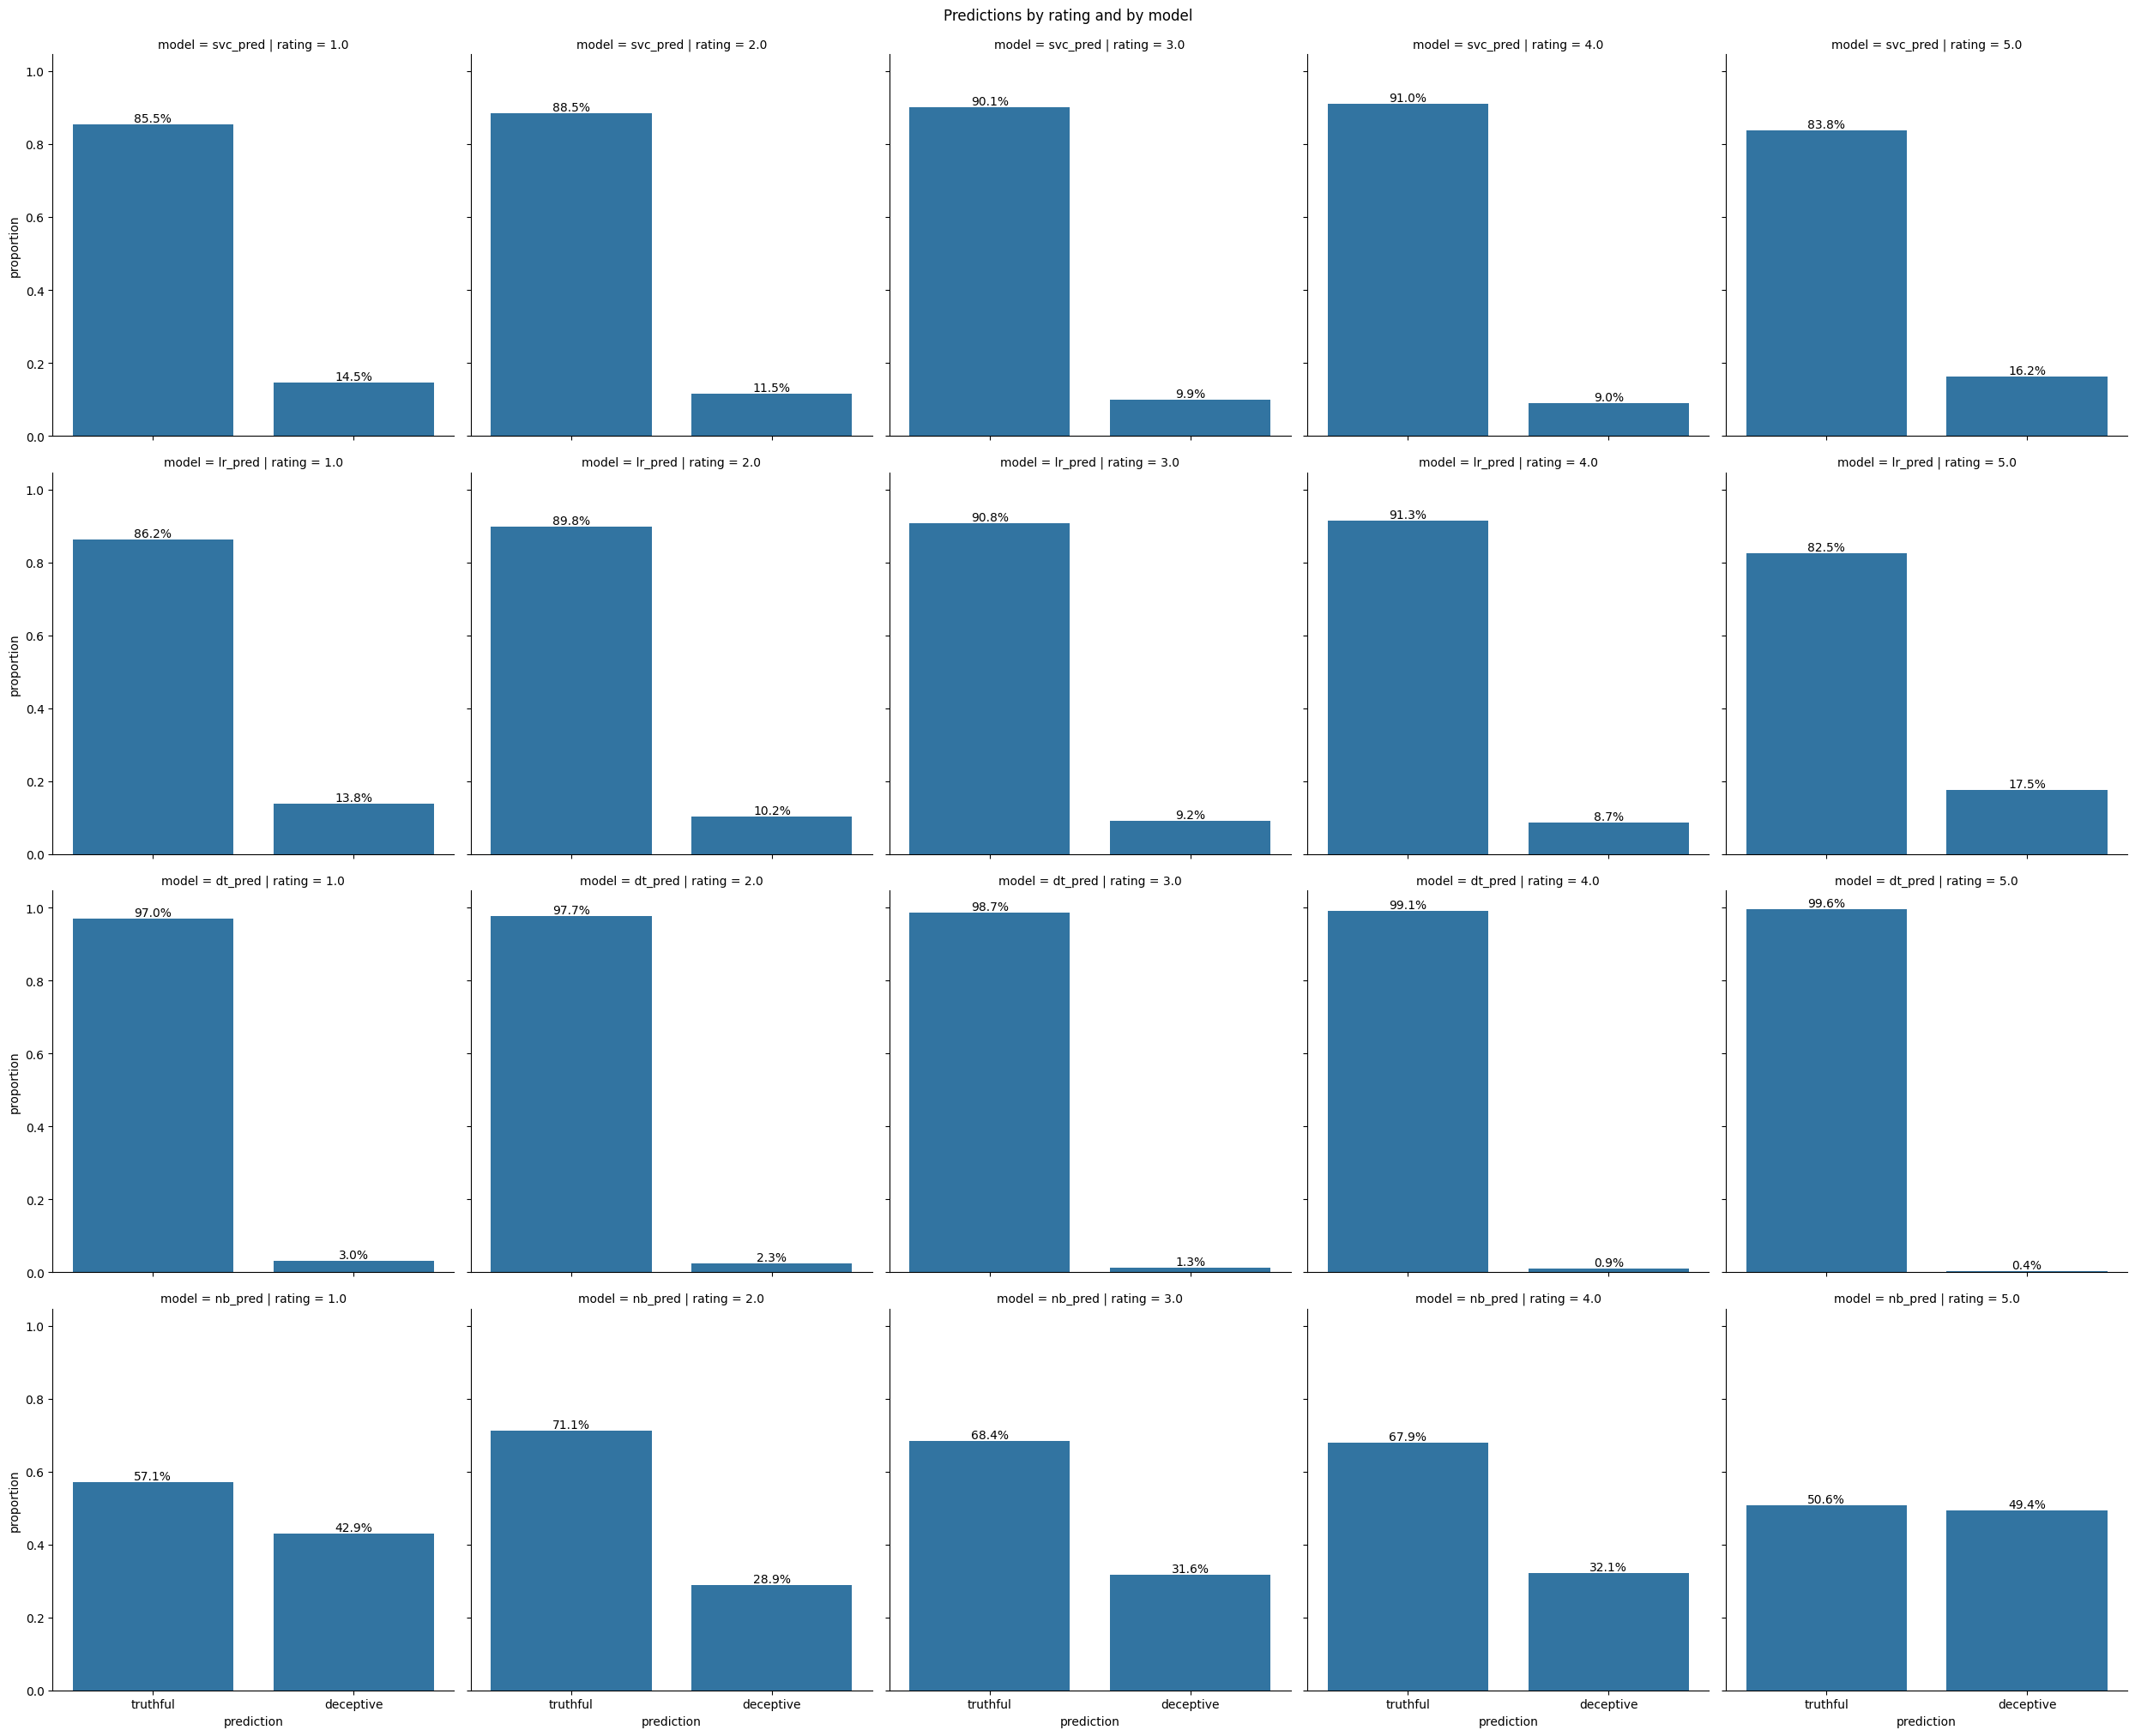

In [42]:
g = sns.FacetGrid(data = preds_long, col='rating', row='model',  height=5)
g.map(sns.countplot, 'prediction', order=['truthful', 'deceptive'], stat='proportion')
g.figure.suptitle(t='Predictions by rating and by model', y=1.01)
for ax in g.axes.flat:
    for patch in ax.patches:
        ax.annotate(
            f"{patch.get_height():.1%}",
            (patch.get_x() + patch.get_width()/2, patch.get_height()),
            ha='center',
            va='bottom'
        )

plt.show()